# Guitar Classifier — Transfer Learning con VGG16

- Nicolas Rodríguez Forero
- Daniel Velasco González

Clasificador de 6 tipos de guitarra usando VGG16 preentrenado en ImageNet.
Las capas convolucionales de VGG16 se congelan; solo se entrenan las capas densas añadidas.

**Clases:**
- fender_jaguar
- fender_stratocaster
- fender_telecaster
- gibson_les_paul_standard
- gibson_les_paul_studio
- ibanez

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import keras
from keras.applications.vgg16 import VGG16, preprocess_input
from keras import layers, Model
from keras.utils import image_dataset_from_directory
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)

TensorFlow version: 2.20.0
Keras version: 3.13.2


## 2. Configuración

In [2]:
DATASET_DIR = "../../guitar-dataset"
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
EPOCHS      = 20

CLASSES = [
    "fender_jaguar",
    "fender_stratocaster",
    "fender_telecaster",
    "gibson_les_paul_standard",
    "gibson_les_paul_studio",
    "ibanez",
]
NUM_CLASSES = len(CLASSES)
print(f"Clases ({NUM_CLASSES}):", CLASSES)

Clases (6): ['fender_jaguar', 'fender_stratocaster', 'fender_telecaster', 'gibson_les_paul_standard', 'gibson_les_paul_studio', 'ibanez']


## 3. Carga del dataset

In [3]:
train_ds = image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
)

val_ds = image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
)

print("Clases detectadas en el directorio:", train_ds.class_names)

Found 120 files belonging to 6 classes.
Using 96 files for training.
Found 120 files belonging to 6 classes.
Using 24 files for validation.
Clases detectadas en el directorio: ['fender_jaguar', 'fender_stratocaster', 'fender_telecaster', 'gibson_les_paul_standard', 'gibson_les_paul_studio', 'ibanez']


## 4. Preprocesamiento VGG16

`preprocess_input` resta la media de los canales BGR calculada sobre ImageNet.
Es necesario aplicarlo para que los pesos preentrenados funcionen correctamente.

In [4]:
def preprocess_batch(images, labels):
    return preprocess_input(images), labels

train_ds = train_ds.map(preprocess_batch, num_parallel_calls=tf.data.AUTOTUNE)
val_ds   = val_ds.map(preprocess_batch,   num_parallel_calls=tf.data.AUTOTUNE)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.prefetch(tf.data.AUTOTUNE)

# Guardar un batch del val set en escala original (0-255) para visualizaciones posteriores
raw_val_ds = image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
)
sample_images_raw, sample_labels_raw = next(iter(raw_val_ds))
print("Batch de ejemplo cargado:", sample_images_raw.shape)

Found 120 files belonging to 6 classes.
Using 24 files for validation.
Batch de ejemplo cargado: (24, 224, 224, 3)


## 5. Construcción del modelo (Transfer Learning)

- Se carga VGG16 **sin** las capas de clasificación originales (`include_top=False`).
- `base_model.trainable = False` congela **todos** los pesos convolucionales.
- Se añaden: `Flatten → Dense(100, relu) → Dense(50, relu) → Dense(6, softmax)`.

In [5]:
base_model = VGG16(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # congelar las capas convolucionales de VGG16

x      = layers.Flatten()(base_model.output)
x      = layers.Dense(100, activation="relu", name="dense_100")(x)
x      = layers.Dense(50,  activation="relu", name="dense_50")(x)
output = layers.Dense(NUM_CLASSES, activation="softmax", name="output")(x)

model = Model(inputs=base_model.input, outputs=output, name="guitar_classifier")
model.summary()

Model: "guitar_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_100 (Dense)               │ (None, 100)            │     2,508,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           306 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,228,944 (65.72 MB)

 Trainable params: 2,514,256 (9.59 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [6]:
# Verificar que solo las capas añadidas son entrenables
trainable   = sum(np.prod(w.shape) for w in model.trainable_weights)
no_trainable = sum(np.prod(w.shape) for w in model.non_trainable_weights)
print(f"Parámetros entrenables:     {trainable:,}")
print(f"Parámetros NO entrenables:  {no_trainable:,}")

Parámetros entrenables:     2,514,256
Parámetros NO entrenables:  14,714,688


## 6. Compilación y entrenamiento

In [7]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
)

Epoch 1/20


2026-04-08 15:49:22.212154: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile


3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - accuracy: 0.2708 - loss: 18.3182 - val_accuracy: 0.1250 - val_loss: 30.2780
Epoch 2/20


2026-04-08 15:49:30.528023: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile


3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step - accuracy: 0.4896 - loss: 11.9815 - val_accuracy: 0.3333 - val_loss: 12.9134
Epoch 3/20


...

3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 3s/step - accuracy: 0.9896 - loss: 0.0192 - val_accuracy: 0.5000 - val_loss: 8.1004
Epoch 19/20


2026-04-08 15:51:41.152362: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile


3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 3s/step - accuracy: 0.9896 - loss: 0.0182 - val_accuracy: 0.5000 - val_loss: 8.1522
Epoch 20/20


2026-04-08 15:51:48.973998: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile


3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step - accuracy: 0.9896 - loss: 0.0258 - val_accuracy: 0.5417 - val_loss: 8.1910


## 7. Curvas de entrenamiento

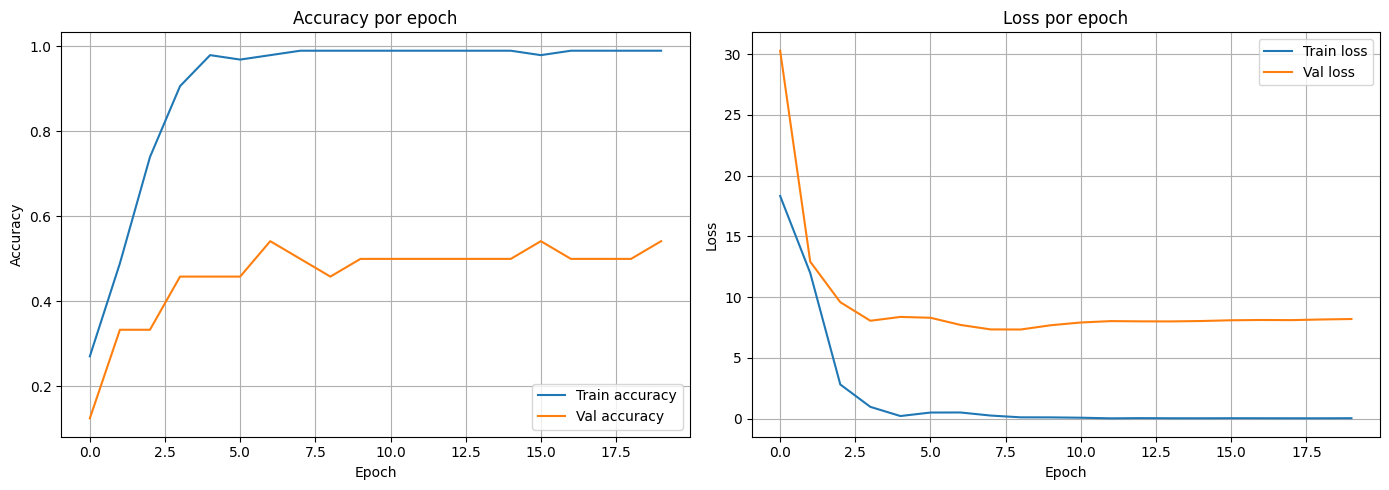

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["accuracy"],     label="Train accuracy")
axes[0].plot(history.history["val_accuracy"], label="Val accuracy")
axes[0].set_title("Accuracy por epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history["loss"],     label="Train loss")
axes[1].plot(history.history["val_loss"], label="Val loss")
axes[1].set_title("Loss por epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 8. Visualización de salidas por capa (Feature Maps)

Se selecciona una imagen de ejemplo y se muestra la activación de los primeros filtros
en cada capa convolucional de los 5 bloques de VGG16.

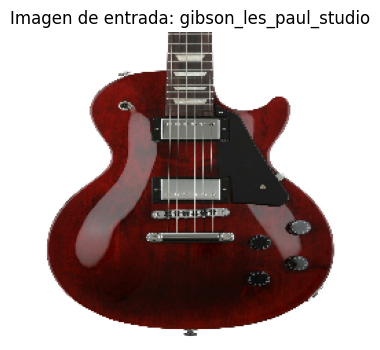

In [9]:
# Seleccionar una imagen de ejemplo (primera del batch de validación)
sample_img_raw = sample_images_raw[0].numpy().astype(np.uint8)
sample_label_idx = int(np.argmax(sample_labels_raw[0].numpy()))
sample_label_name = CLASSES[sample_label_idx]

plt.figure(figsize=(4, 4))
plt.imshow(sample_img_raw)
plt.title(f"Imagen de entrada: {sample_label_name}")
plt.axis("off")
plt.show()

In [10]:
# Modelo para extraer salidas de cada capa convolucional
conv_layers = [layer for layer in model.layers if "conv" in layer.name]
layer_names = [layer.name for layer in conv_layers]
layer_outputs = [layer.output for layer in conv_layers]

activation_model = Model(inputs=model.input, outputs=layer_outputs)

# Preprocesar la imagen de entrada para el modelo
img_input = np.expand_dims(sample_images_raw[0].numpy(), axis=0)
img_input_preprocessed = preprocess_input(img_input)

activations = activation_model.predict(img_input_preprocessed, verbose=0)

print(f"Número de capas convolucionales: {len(conv_layers)}")
for name, act in zip(layer_names, activations):
    print(f"  {name}: {act.shape}")

Número de capas convolucionales: 13
  block1_conv1: (1, 224, 224, 64)
  block1_conv2: (1, 224, 224, 64)
  block2_conv1: (1, 112, 112, 128)
  block2_conv2: (1, 112, 112, 128)
  block3_conv1: (1, 56, 56, 256)
  block3_conv2: (1, 56, 56, 256)
  block3_conv3: (1, 56, 56, 256)
  block4_conv1: (1, 28, 28, 512)
  block4_conv2: (1, 28, 28, 512)
  block4_conv3: (1, 28, 28, 512)
  block5_conv1: (1, 14, 14, 512)
  block5_conv2: (1, 14, 14, 512)
  block5_conv3: (1, 14, 14, 512)


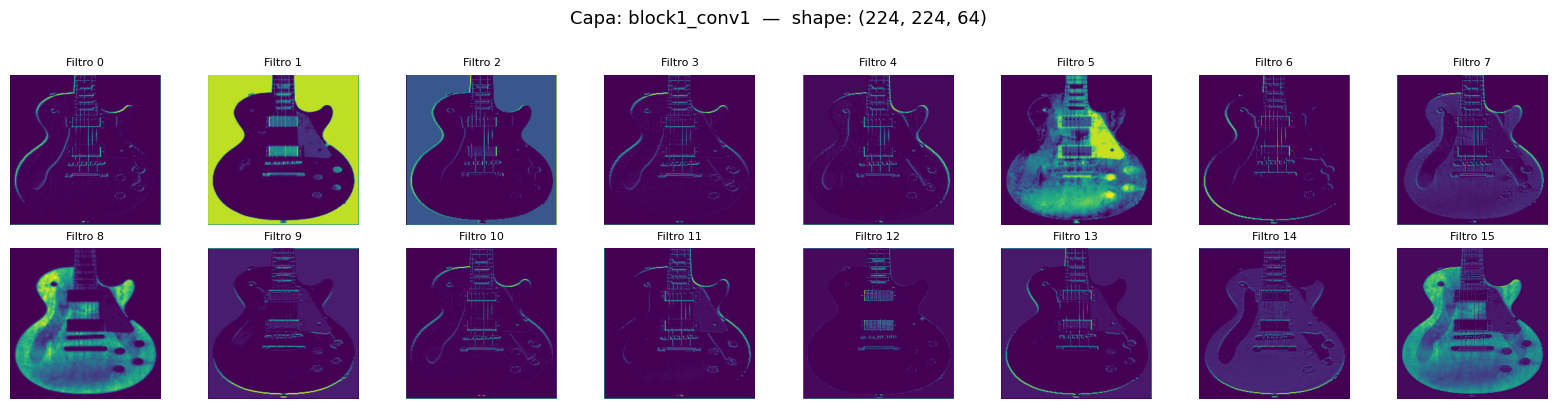

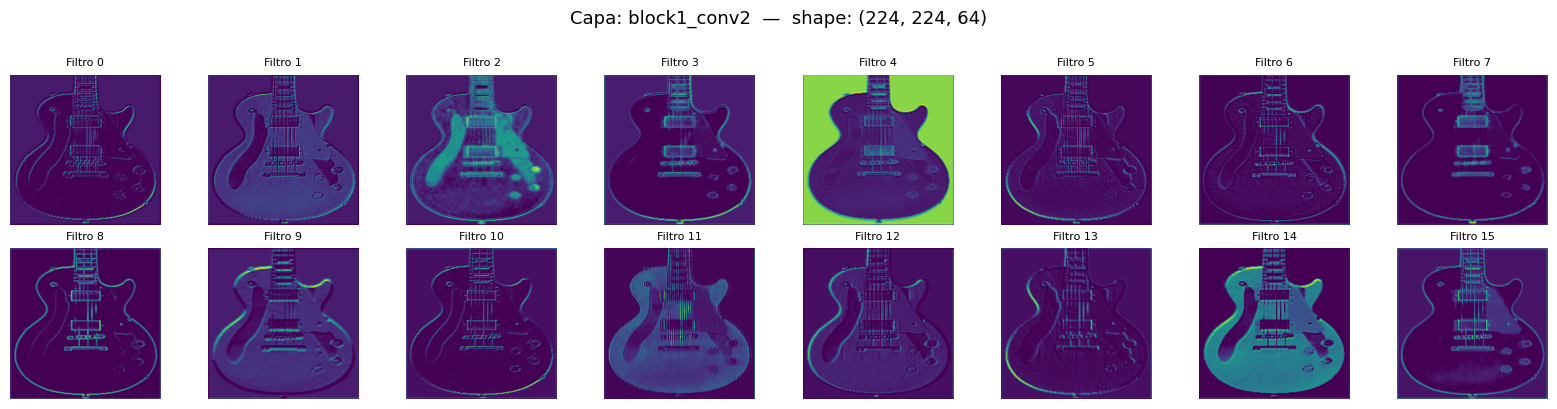

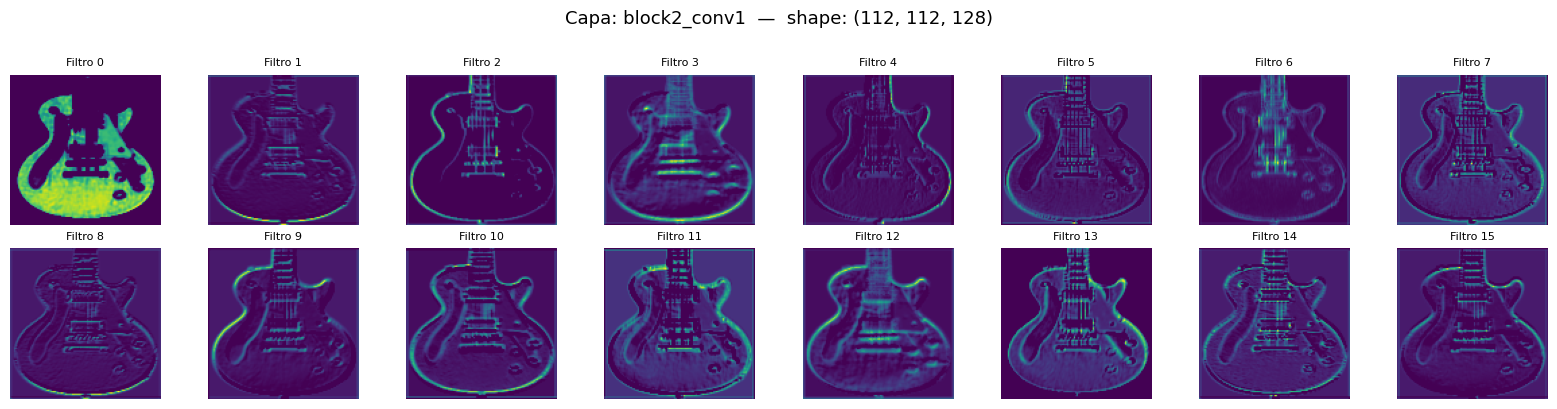

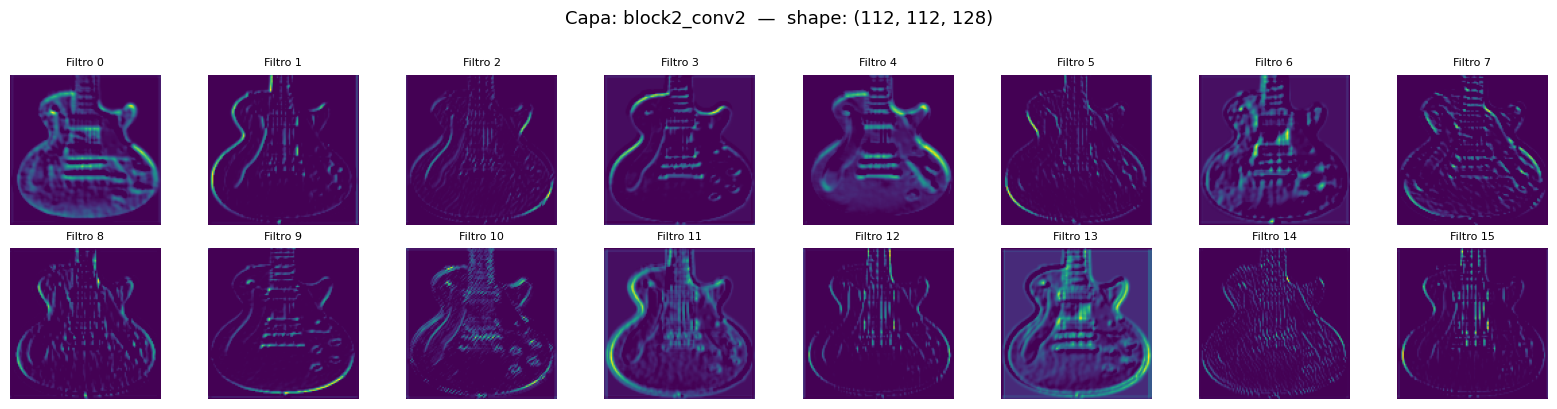

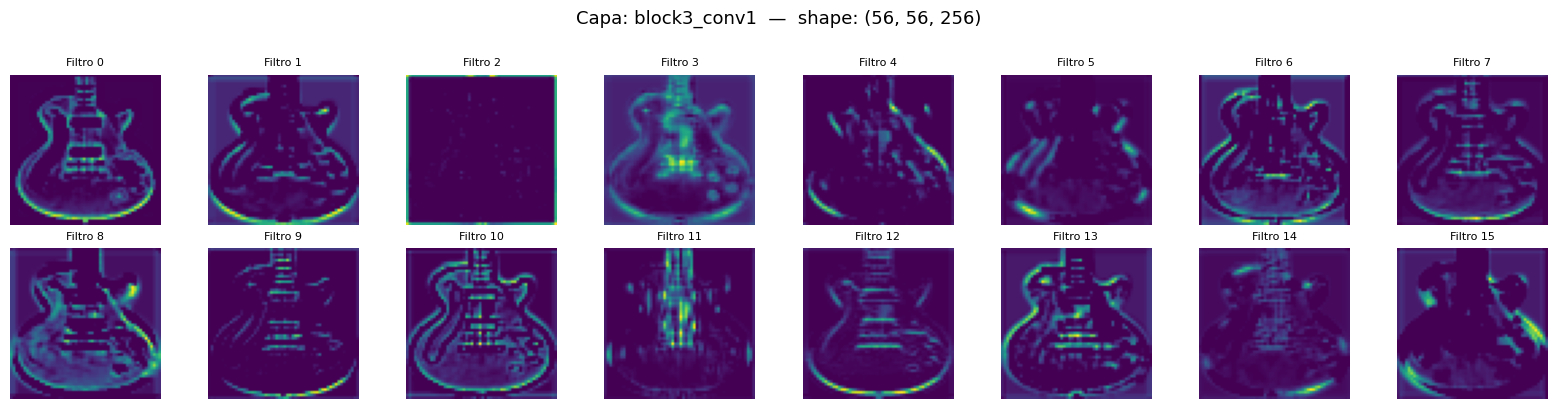

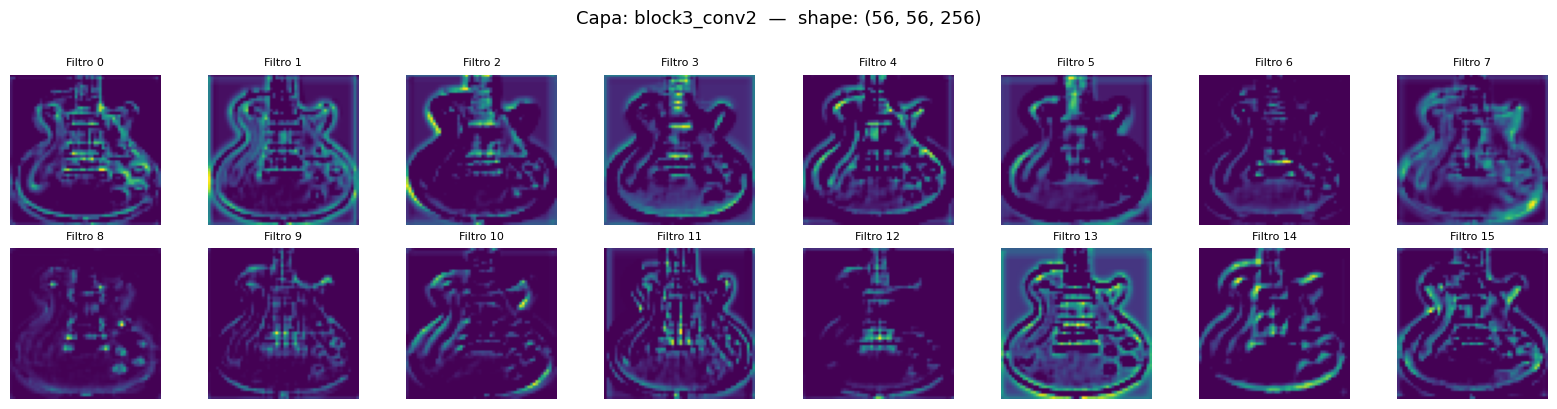

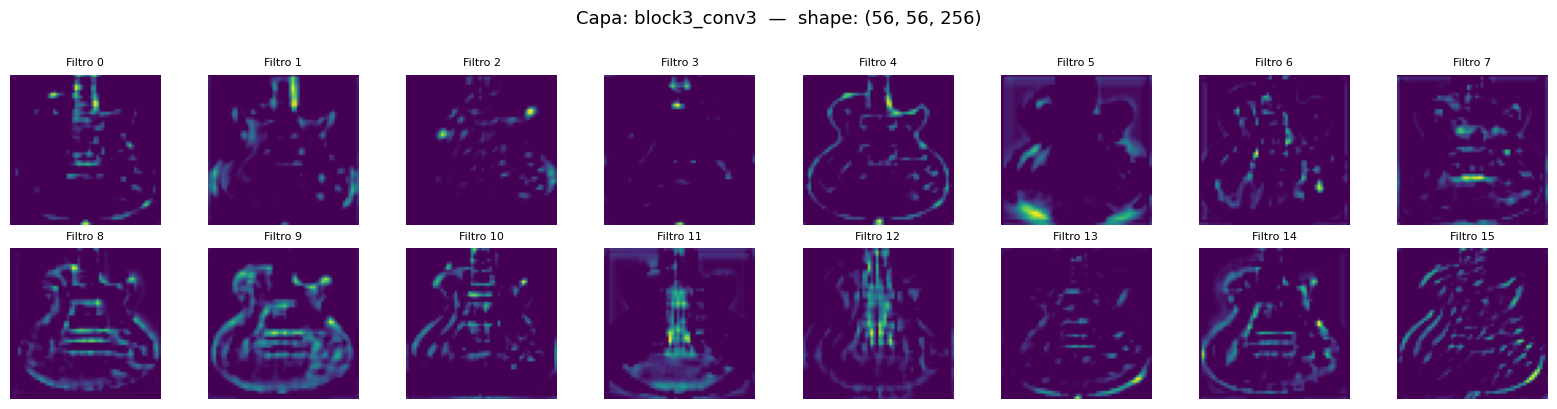

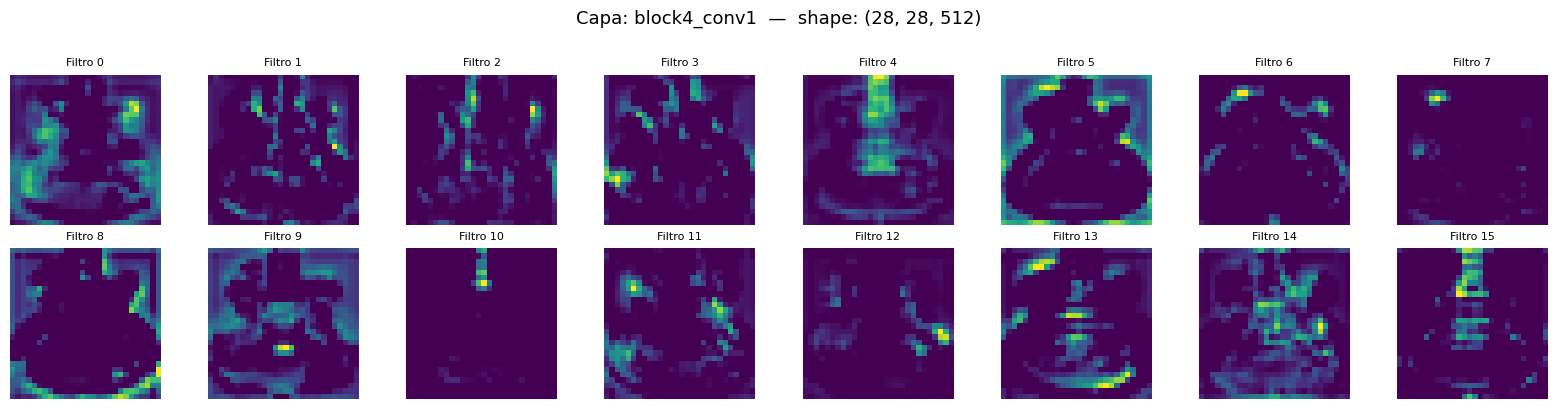

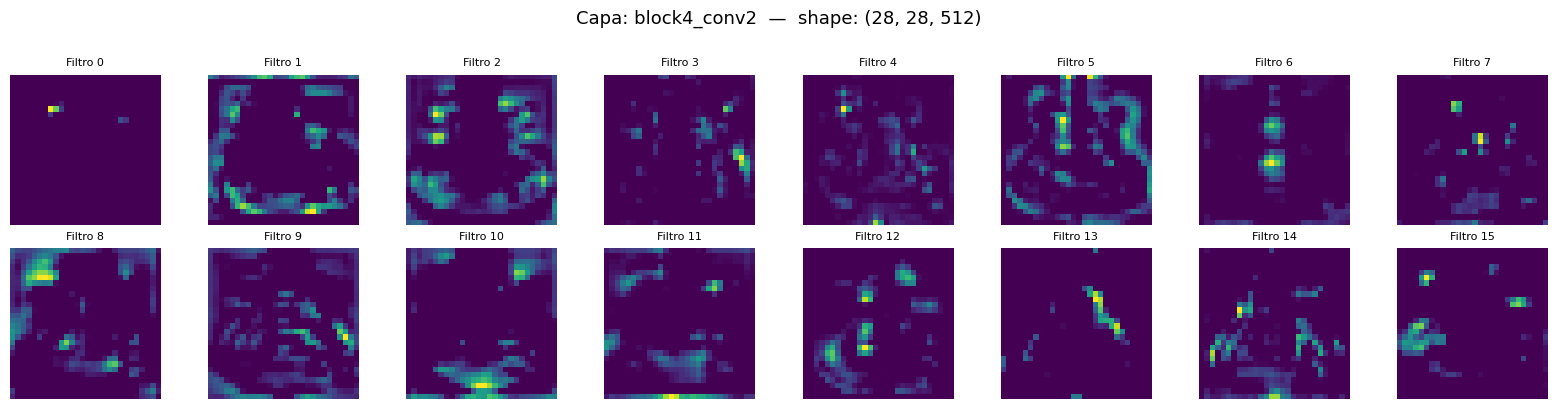

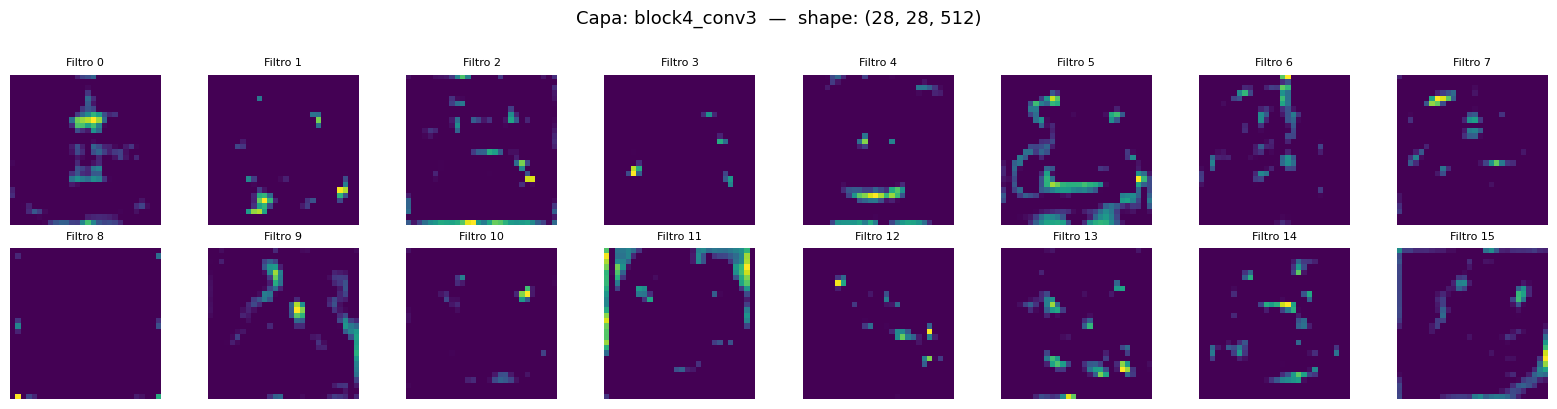

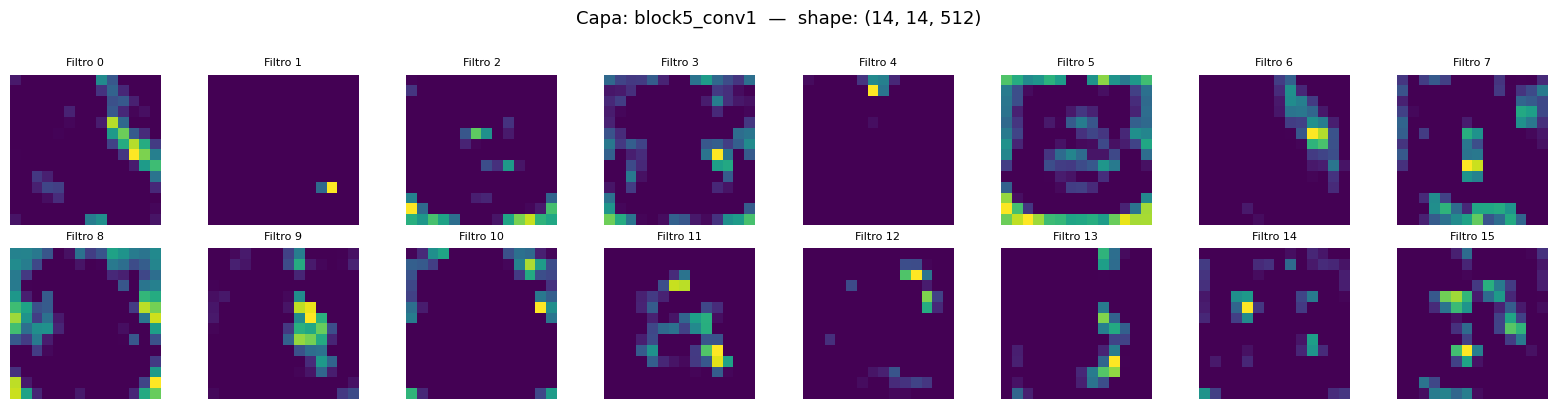

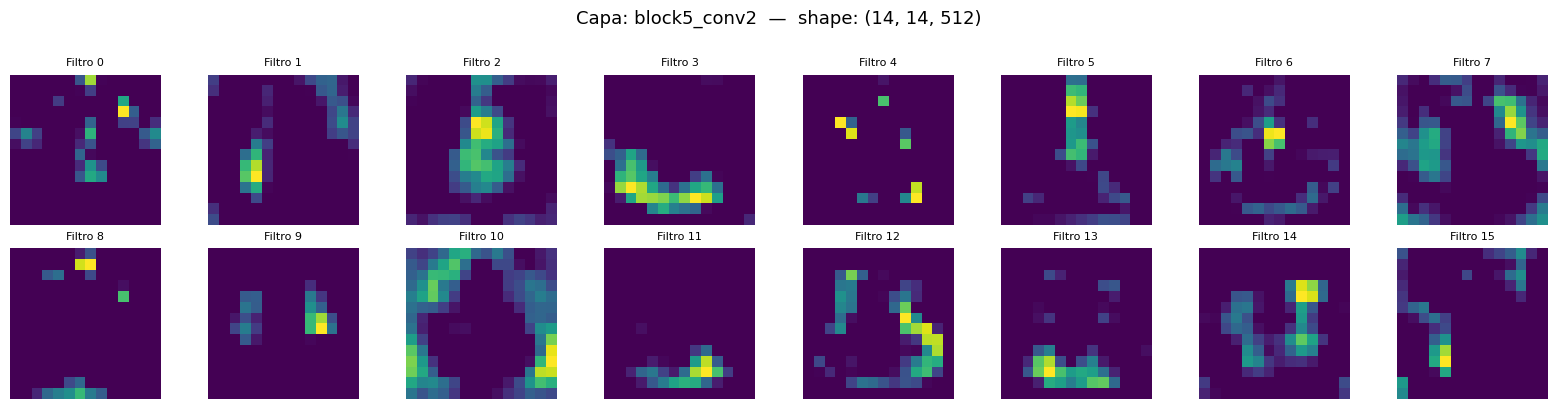

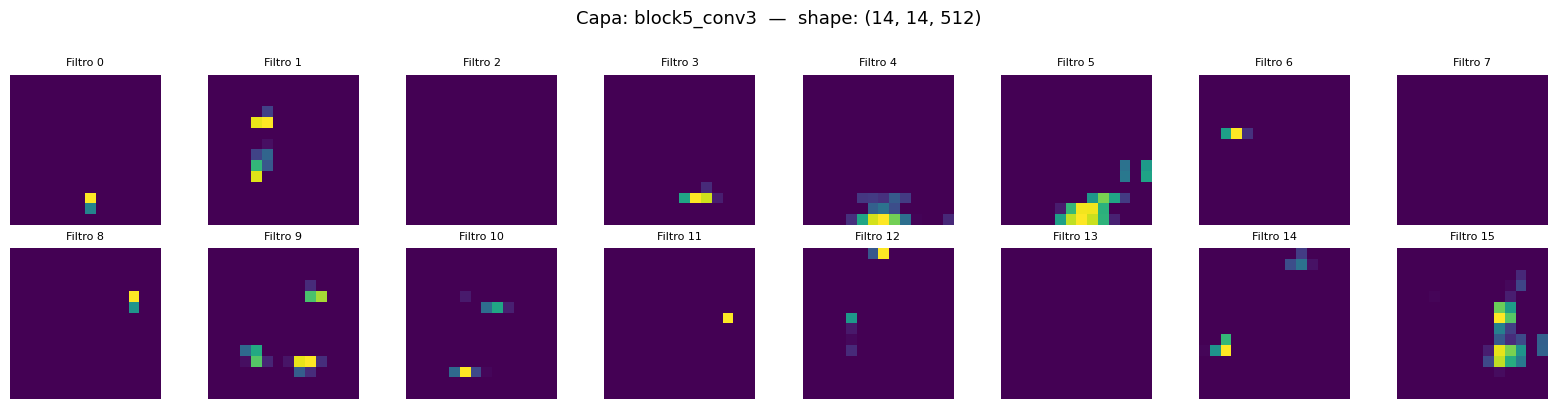

In [11]:
# Visualizar los primeros 16 filtros de cada capa convolucional
N_FILTERS = 16

for layer_name, activation in zip(layer_names, activations):
    n_filters = min(N_FILTERS, activation.shape[-1])
    cols = 8
    rows = int(np.ceil(n_filters / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    fig.suptitle(f"Capa: {layer_name}  —  shape: {activation.shape[1:]}",
                 fontsize=13, y=1.01)

    axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes.flatten()

    for i in range(n_filters):
        feature_map = activation[0, :, :, i]
        axes[i].imshow(feature_map, cmap="viridis")
        axes[i].set_title(f"Filtro {i}", fontsize=8)
        axes[i].axis("off")

    for j in range(n_filters, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

## 9. Evaluación: Accuracy, Precision, Recall y Matriz de Confusión

In [12]:
# Recolectar predicciones sobre el conjunto de validación
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(f"Total imágenes evaluadas: {len(y_true)}")

Total imágenes evaluadas: 24


2026-04-08 15:52:00.256709: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [13]:
# Reporte de clasificación: accuracy, precision, recall, f1 por clase
print("=" * 65)
print("Reporte de clasificación")
print("=" * 65)
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))

Reporte de clasificación
                          precision    recall  f1-score   support

           fender_jaguar     1.0000    0.6667    0.8000         3
     fender_stratocaster     0.0000    0.0000    0.0000         5
       fender_telecaster     0.4000    1.0000    0.5714         2
gibson_les_paul_standard     0.4286    1.0000    0.6000         3
  gibson_les_paul_studio     0.6667    0.4000    0.5000         5
                  ibanez     1.0000    0.6667    0.8000         6

                accuracy                         0.5417        24
               macro avg     0.5825    0.6222    0.5452        24
            weighted avg     0.6008    0.5417    0.5268        24



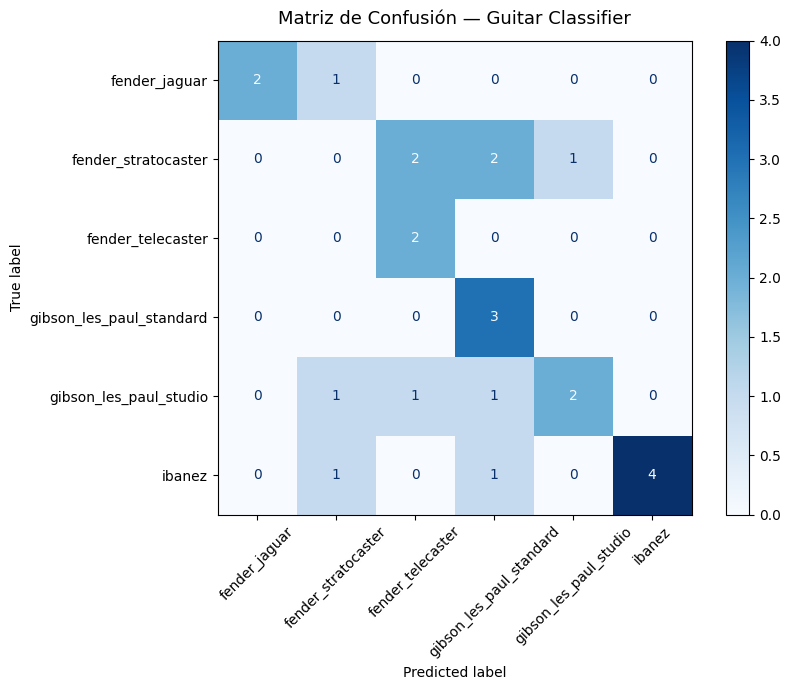

In [14]:
# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(ax=ax, xticks_rotation=45, colorbar=True, cmap="Blues")
ax.set_title("Matriz de Confusión — Guitar Classifier", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

In [15]:
# Resumen de métricas globales
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
rec  = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1   = f1_score(y_true, y_pred, average="macro", zero_division=0)

print(f"Accuracy (global):          {acc:.4f}")
print(f"Precision (macro avg):      {prec:.4f}")
print(f"Recall    (macro avg):      {rec:.4f}")
print(f"F1-score  (macro avg):      {f1:.4f}")

Accuracy (global):          0.5417
Precision (macro avg):      0.5825
Recall    (macro avg):      0.6222
F1-score  (macro avg):      0.5452
